In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
import warnings
warnings.filterwarnings
warnings.filterwarnings('ignore')
df=pd.read_csv('autism_dataset.csv')
print(df.head())

   ID  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0   1         1         0         1         0         1         0         1   
1   2         0         0         0         0         0         0         0   
2   3         1         1         1         1         1         1         1   
3   4         0         0         0         0         0         0         0   
4   5         0         0         0         0         0         0         0   

   A8_Score  A9_Score  ...  gender       ethnicity jaundice austim  \
0         0         1  ...       f               ?       no     no   
1         0         0  ...       m               ?       no     no   
2         1         1  ...       m  White-European       no    yes   
3         0         0  ...       f               ?       no     no   
4         0         0  ...       m               ?       no     no   

   contry_of_res used_app_before     result     age_desc  relation Class/ASD  
0        Austria         

In [16]:
df.shape

(800, 22)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,800.0,400.500000,231.084400,1.000000,200.750000,400.500000,600.250000,800.000000
A1_Score,800.0,0.560000,0.496697,0.000000,0.000000,1.000000,1.000000,1.000000
A2_Score,800.0,0.530000,0.499411,0.000000,0.000000,1.000000,1.000000,1.000000
A3_Score,800.0,0.450000,0.497805,0.000000,0.000000,0.000000,1.000000,1.000000
A4_Score,800.0,0.415000,0.493030,0.000000,0.000000,0.000000,1.000000,1.000000
A5_Score,800.0,0.395000,0.489157,0.000000,0.000000,0.000000,1.000000,1.000000
A6_Score,800.0,0.303750,0.460164,0.000000,0.000000,0.000000,1.000000,1.000000
A7_Score,800.0,0.397500,0.489687,0.000000,0.000000,0.000000,1.000000,1.000000
A8_Score,800.0,0.508750,0.500236,0.000000,0.000000,1.000000,1.000000,1.000000
A9_Score,800.0,0.495000,0.500288,0.000000,0.000000,0.000000,1.000000,1.000000


In [22]:
df['ethnicity'].value_counts()

ethnicity
White-European     257
?                  203
Middle Eastern      97
Asian               67
Black               47
South Asian         34
Pasifika            32
Others              29
Latino              17
Hispanic             9
Turkish              5
others               3
Name: count, dtype: int64

In [24]:
df['relation'].value_counts()

relation
Self                        709
?                            40
Parent                       29
Relative                     18
Others                        2
Health care professional      2
Name: count, dtype: int64

In [26]:
print(df.columns)

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')


In [28]:
df.columns = df.columns.str.strip()

In [30]:
print(df.columns)
df=df.replace({'yes':1,'no':0,'?':'others','other':'others'})

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')


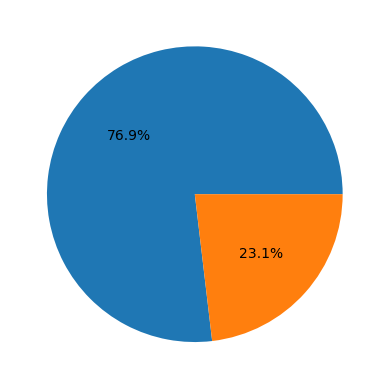

In [32]:
plt.pie(df['jaundice'].value_counts().values, autopct='%1.1f%%')
plt.show()

In [34]:
#using pandas select_dtypes method to seperate column by dtype
int_columns = df.select_dtypes(include=['int64', 'int32']).columns.tolist()
object_columns = df.select_dtypes(include=['object']).columns.tolist()
float_columns = df.select_dtypes(include=['float64', 'float32']).columns.tolist()

# Print results
print("Integer columns:", int_columns)
print("Float columns:", float_columns)
print("Object columns:", object_columns)

Integer columns: ['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'jaundice', 'austim', 'used_app_before', 'Class/ASD']
Float columns: ['age', 'result']
Object columns: ['gender', 'ethnicity', 'contry_of_res', 'age_desc', 'relation']


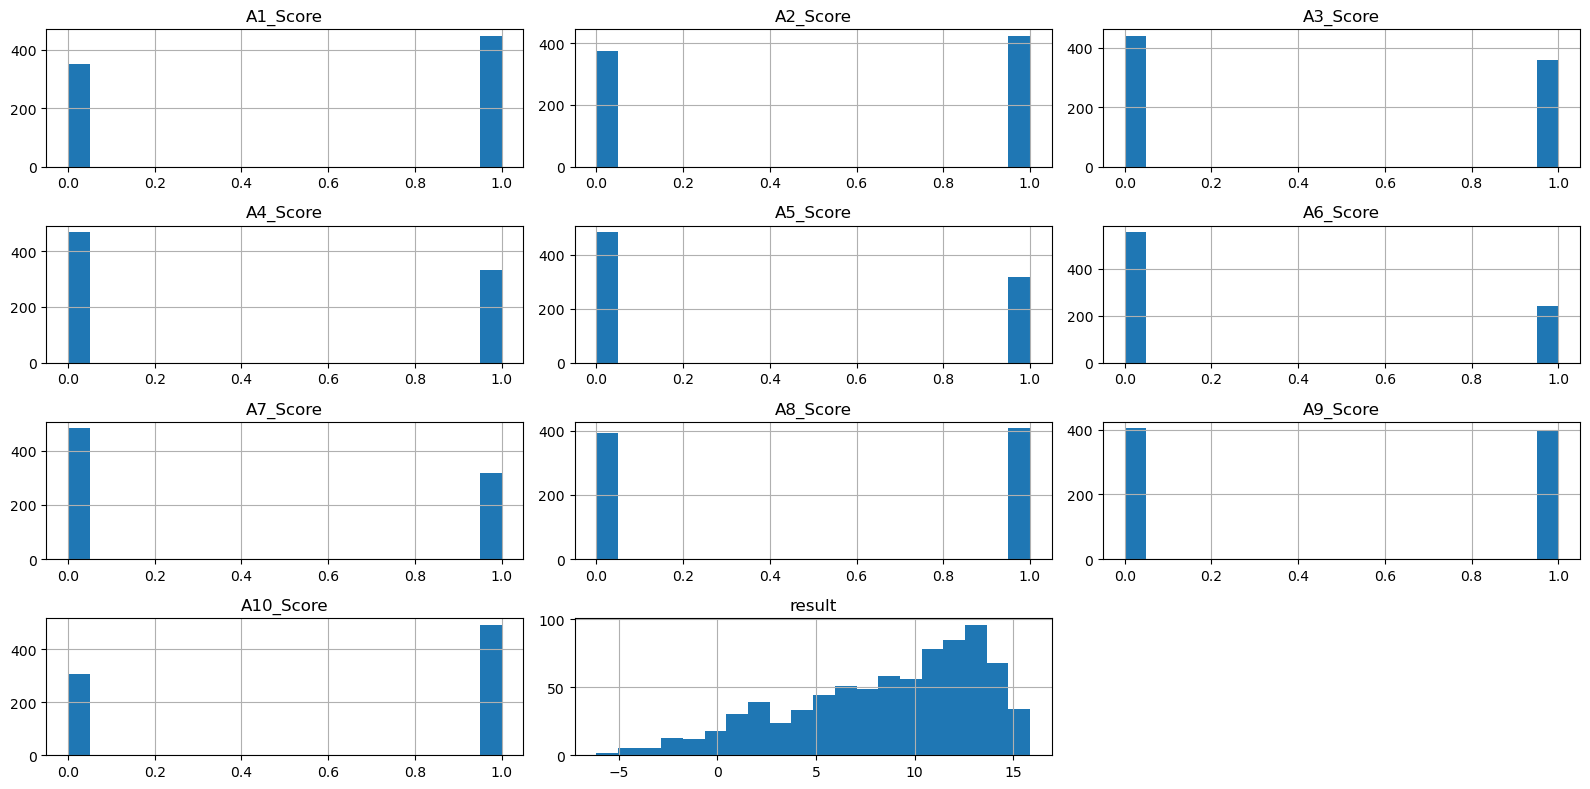

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histogram for continues variables
import matplotlib.pyplot as plt

def plot_histogram(df):
    continuous_columns = ['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','gender','result']
    # create subplots with specified figsize as a tuple
    df[continuous_columns].hist(bins=20, figsize=(16, 8))
    plt.tight_layout()
    plt.show()

# 2. Boxplot for continuous variables (to check outliers)
def plot_boxplot(df):
    continuous_columns=['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','gender','result']
    plt.figure(figsize=(15,10))
    sns.boxplot(data=df[continuous_columns],orient='h')
    plt.show()

# plot histogram
plot_histogram(df)

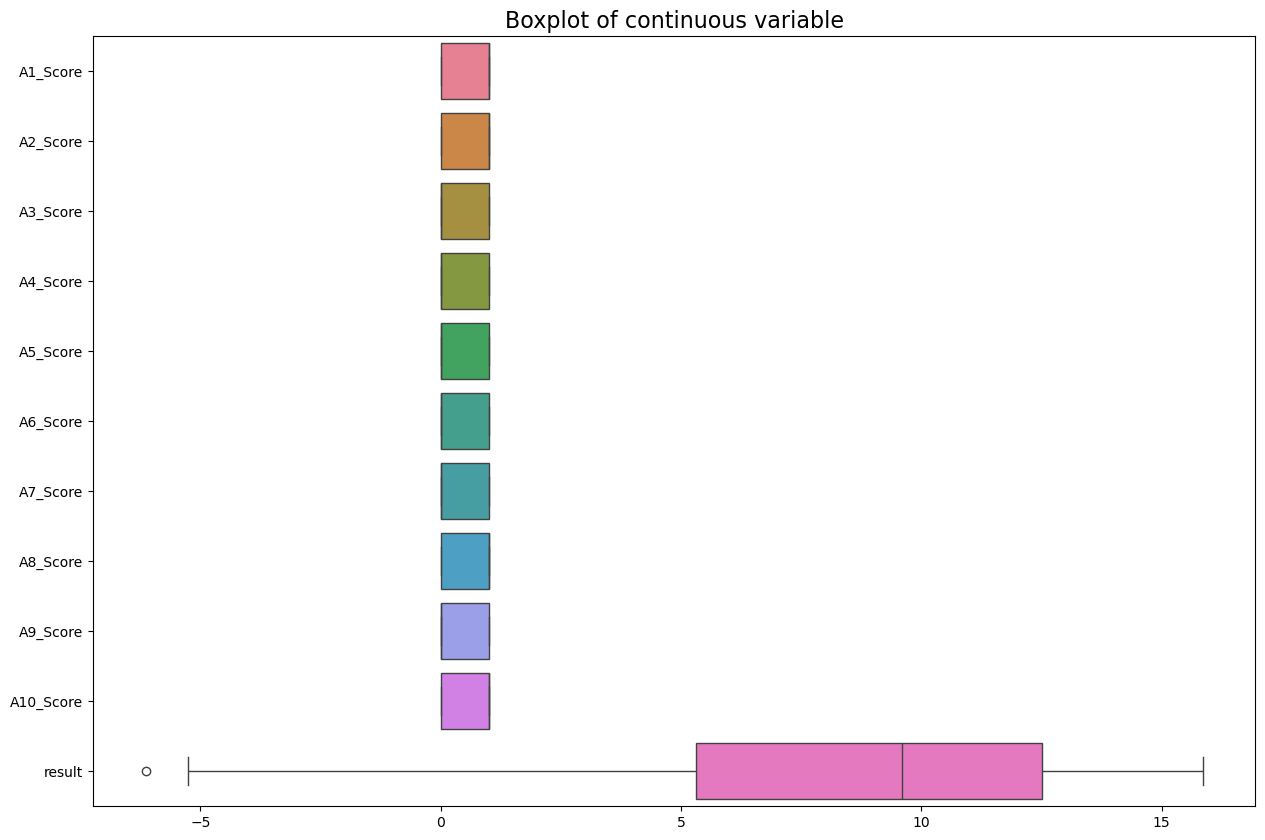

In [37]:
# 2 . Boxplot for continuous variable(to check outliers)
def plot_boxplots(df):
    continuous_columns=['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','gender','result']
    plt.figure(figsize=(15,10))
    sns.boxplot(data=df[continuous_columns],orient='h')
    plt.title('Boxplot of continuous variable',fontsize=16)
    plt.show()

#plot Boxplots
plot_boxplots(df)

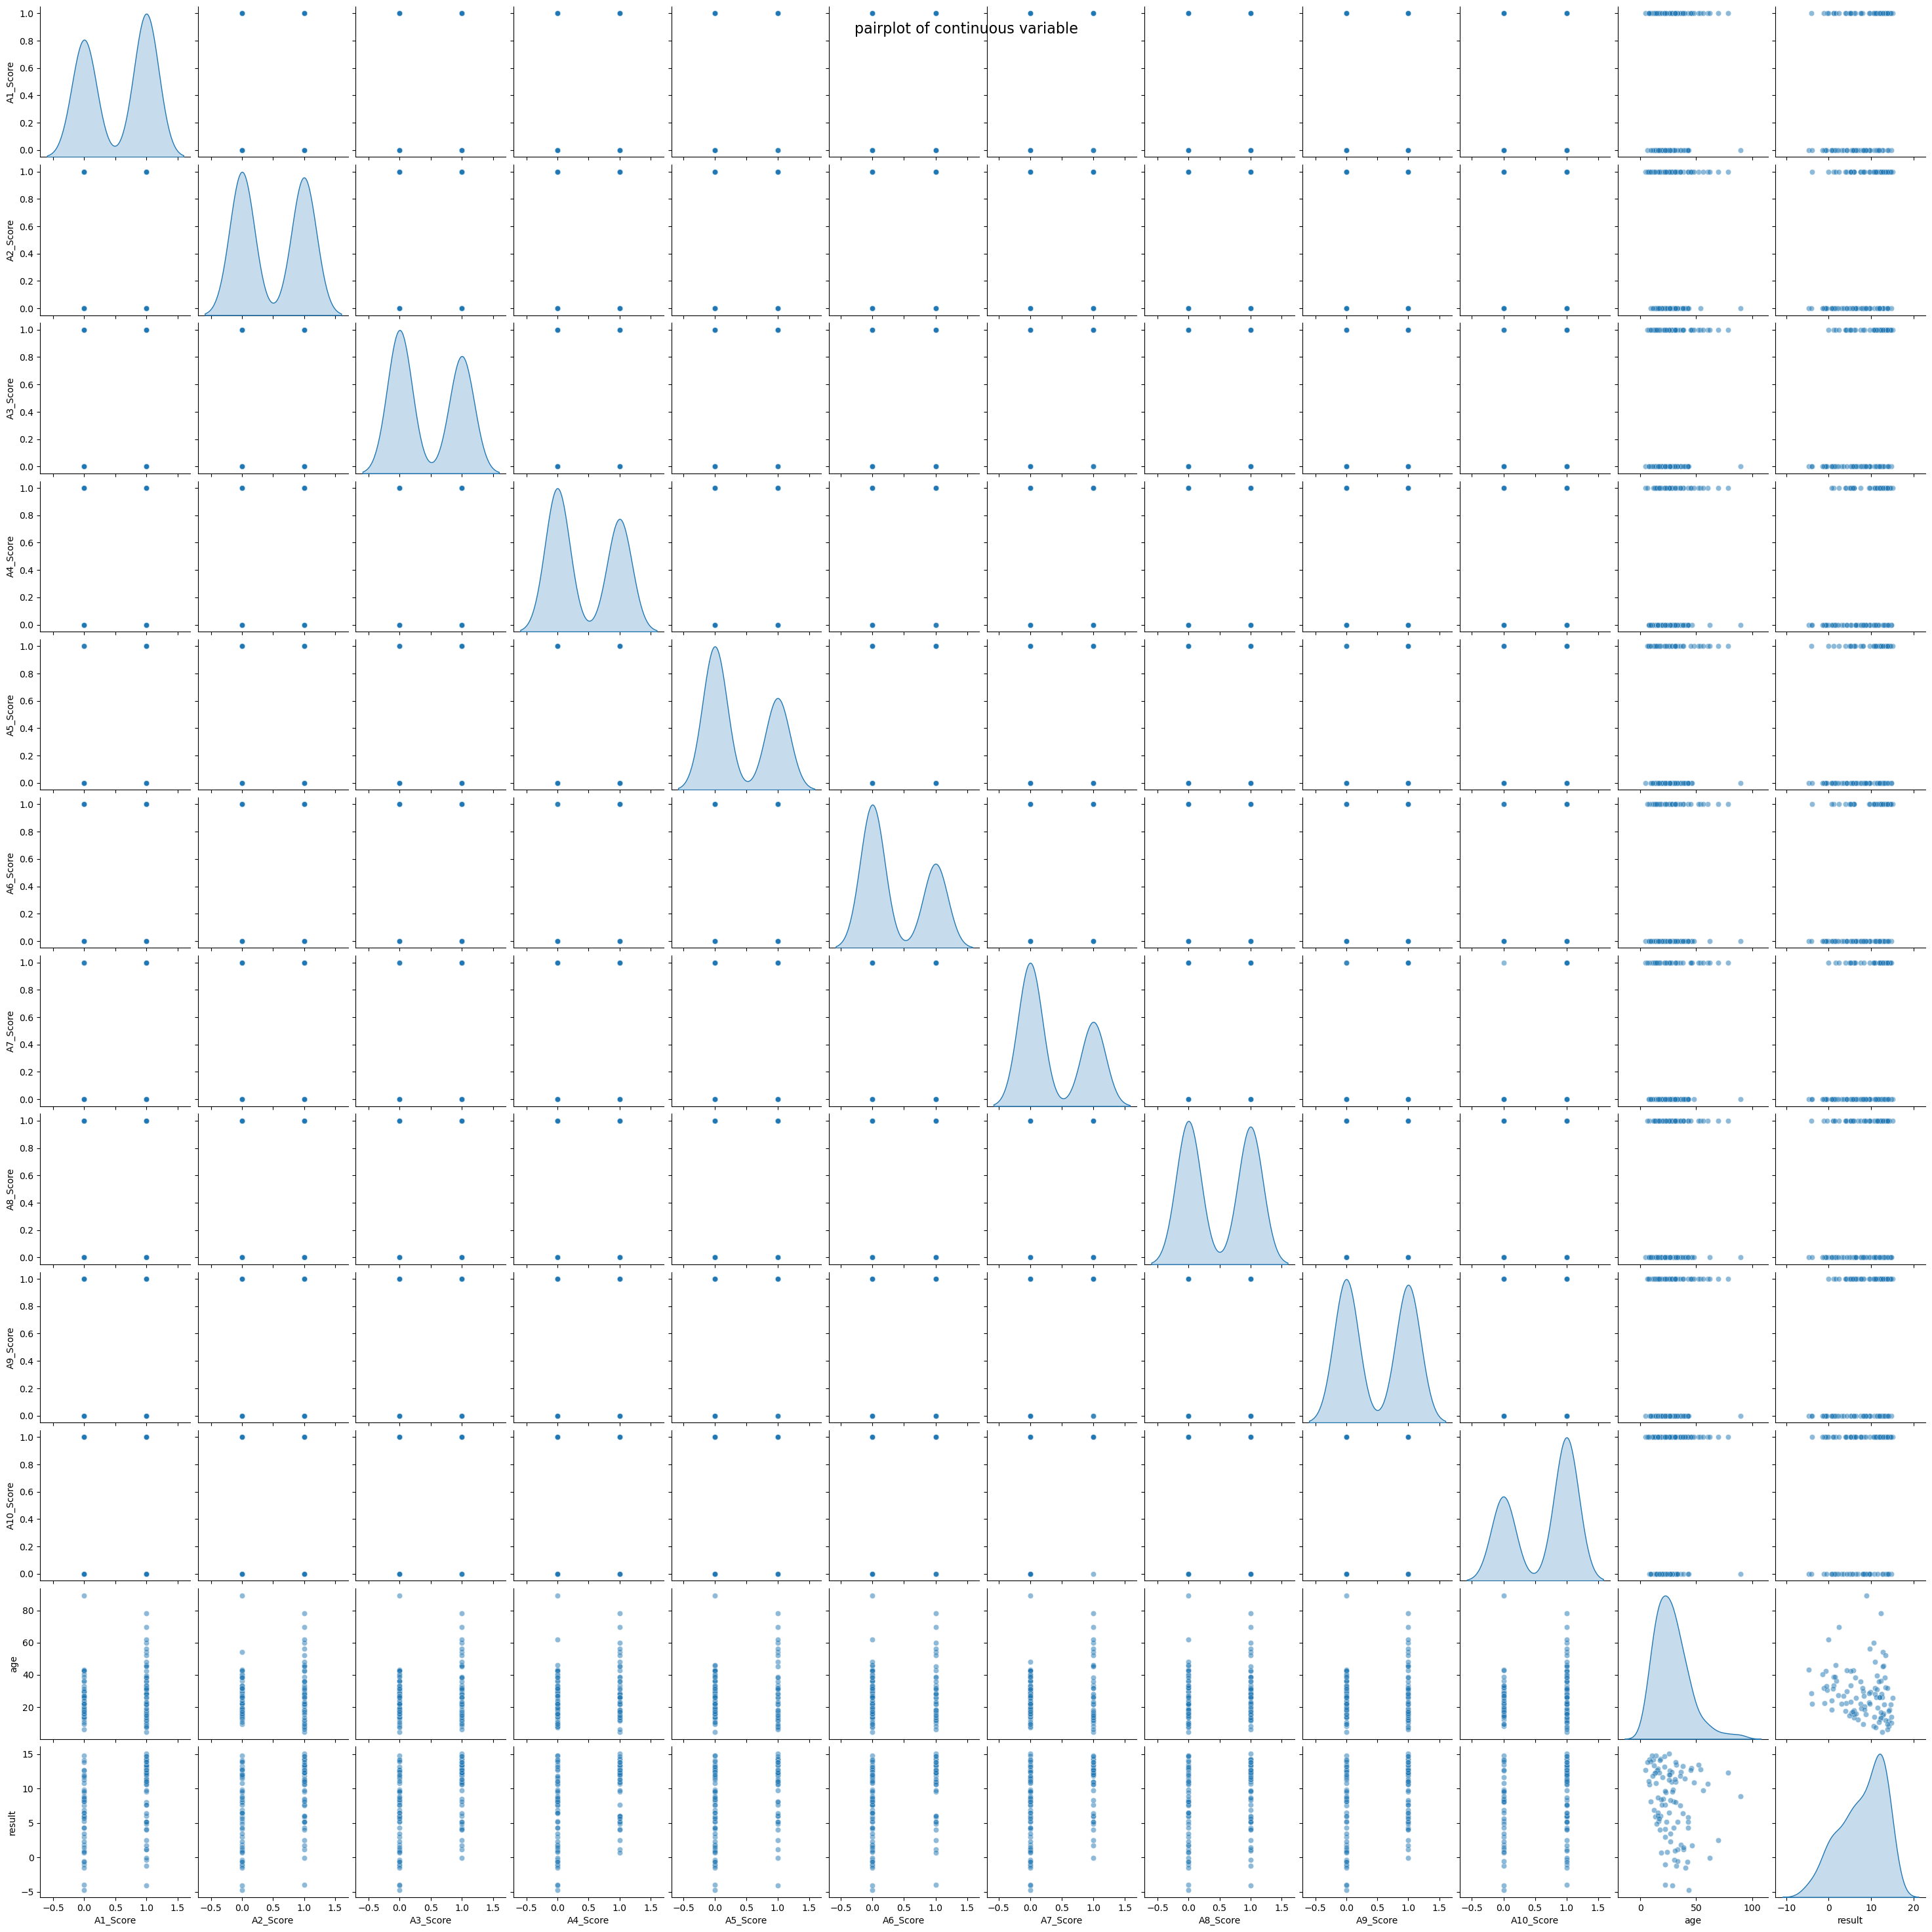

In [40]:
# 3 . Pairplot to visualize relationship between variable
def plot_pairplot(df):
    continuous_columns=['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','age','result']

    #selecting a subset of continuous variables
    sns.pairplot(df[continuous_columns].sample(100),diag_kind='kde',plot_kws={'alpha':0.5})
    plt.suptitle('pairplot of continuous variable',fontsize=16)
    plt.show()

# plot pairplot
plot_pairplot(df)

In [41]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'float64':
            val=df[col].median()
            df[col]=df[col].fillna(val)
        else:
            df=df.dropna(subset=df.select_dtypes(include=['object'])).columns

In [44]:
df=df.drop(df[df['age']==383].index)

In [46]:
for i in df.columns:
    if df[i].dtypes=='object':
        print(df[i].value_counts())
        print("\n")

gender
m    530
f    270
Name: count, dtype: int64


ethnicity
White-European     257
others             206
Middle Eastern      97
Asian               67
Black               47
South Asian         34
Pasifika            32
Others              29
Latino              17
Hispanic             9
Turkish              5
Name: count, dtype: int64


contry_of_res
United States           134
India                   108
New Zealand              78
United Kingdom           67
Jordan                   55
United Arab Emirates     40
Australia                37
Canada                   30
Afghanistan              22
Netherlands              20
Austria                  18
Sri Lanka                17
Brazil                   12
Spain                    10
France                   10
Kazakhstan               10
Ireland                   9
Iran                      8
Russia                    7
South Africa              6
Italy                     6
Bahamas                   6
Malaysia                  

In [48]:
df.drop(columns="age_desc",inplace=True)

In [50]:
df['relation'] = df['relation'].replace('?', 'others')
df['ethnicity'] = df['ethnicity'].replace({'?': 'others', 'others': 'others'})

In [52]:
for i in df.columns:
    if df[i].dtypes=="object":
        print(df[i].value_counts())
        print("\n")

gender
m    530
f    270
Name: count, dtype: int64


ethnicity
White-European     257
others             206
Middle Eastern      97
Asian               67
Black               47
South Asian         34
Pasifika            32
Others              29
Latino              17
Hispanic             9
Turkish              5
Name: count, dtype: int64


contry_of_res
United States           134
India                   108
New Zealand              78
United Kingdom           67
Jordan                   55
United Arab Emirates     40
Australia                37
Canada                   30
Afghanistan              22
Netherlands              20
Austria                  18
Sri Lanka                17
Brazil                   12
Spain                    10
France                   10
Kazakhstan               10
Ireland                   9
Iran                      8
Russia                    7
South Africa              6
Italy                     6
Bahamas                   6
Malaysia                  

In [54]:
print(df['jaundice'].value_counts(),"\n",df['austim'].value_counts())

jaundice
0    615
1    185
Name: count, dtype: int64 
 austim
0    669
1    131
Name: count, dtype: int64


In [56]:
# Drop the 'jaundice' column
x = df.drop(columns=['jaundice'])
y = df['jaundice']

# Correct the column name 'austim' -> 'autism'
cols_to_encode = ['gender', 'ethnicity', 'autism', 'country_of_res', 'used_app_before', 'relation']

# Ensure all columns exist in the DataFrame before encoding
existing_cols = [col for col in cols_to_encode if col in x.columns]

# Apply label encoding to x
label_encoder_x = LabelEncoder()
for col in existing_cols:
    x[col] = label_encoder_x.fit_transform(x[col])

# Apply label encoding to y
label_encoder_y = LabelEncoder()
y = label_encoder_y.fit_transform(y)

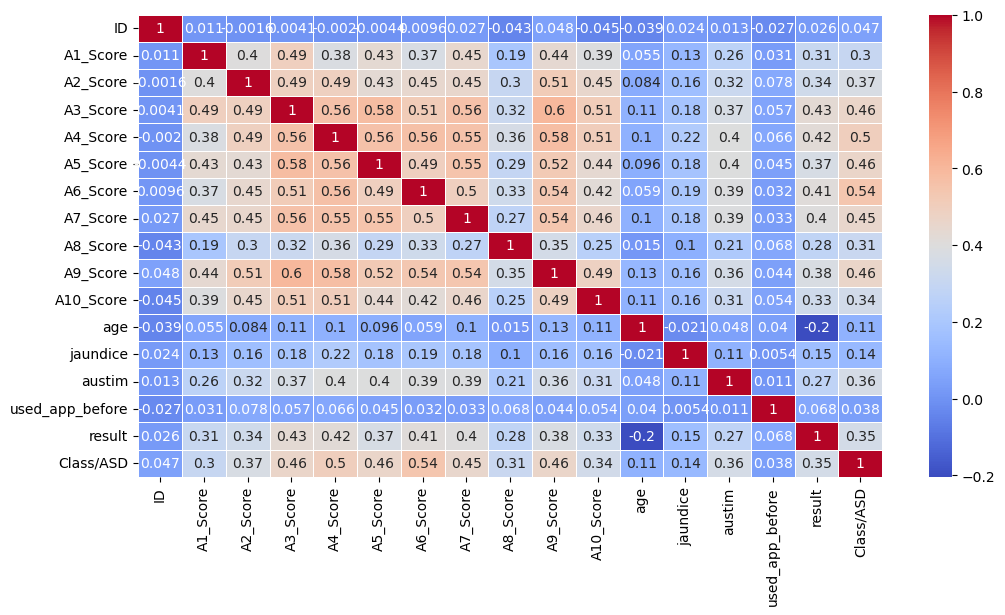

In [58]:
# Select only numeric columns
numeric_x = df.select_dtypes(include=['number'])

# Compute correlation matrix
correlation_matrix = numeric_x.corr()

# Plot heatmap if matrix is not empty
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.show()

In [60]:
# Select only numeric columns
x_numeric = x.select_dtypes(include=['number'])

# Splitting dataset
x_train, x_test, y_train, y_test = train_test_split(x_numeric, y, test_size=0.2, random_state=42)

# Normalize data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [62]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler

def augment_data(x, y, method):
    if method == 'smote':
        sampler = SMOTE(random_state=10, k_neighbors=1)
    elif method == 'randomoversampler':
        sampler = RandomOverSampler(random_state=11)
    else:
        raise ValueError("Invalid method. Choose 'smote' or 'randomoversampler'")
    
    x_resampled, y_resampled = sampler.fit_resample(x, y)
    
    # Convert to DataFrame or NumPy array
    x_resampled = pd.DataFrame(x_resampled)  # Or use np.array(x_resampled)
    y_resampled = np.array(y_resampled)  # Ensure consistency
    
    return x_resampled, y_resampled

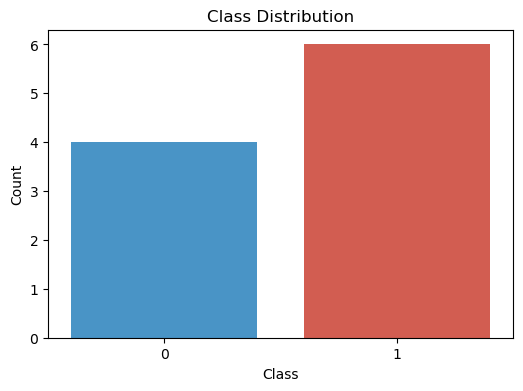

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(y_train_rov):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y_train_rov, palette=["#3498db", "#e74c3c"])  # Blue for class 0, Red for class 1
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

# Define y_train_rov
y_train_rov = [0, 1, 1, 0, 0, 1, 1, 0, 1, 1]  

# Call the function
plot_class_distribution(y_train_rov)


In [66]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [68]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [70]:
def plot_class_distrubution(y_train):
    class_distribution = pd.Series(y_train).value_counts()  # Fix typo in variable name
    plt.figure(figsize=(8, 6))
    sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')  # Use .values instead of .value
    plt.title('Class Distribution in Training Data')
    plt.xlabel('Class')
    plt.ylabel('Number of Samples')
    plt.show()

In [72]:
def augment_data(x, y, method):
    class_counts = pd.Series(y).value_counts()

    # If any class has 1 sample, switch to RandomOverSampler
    if class_counts.min() < 2:
        print("Warning: Some classes have fewer than 2 samples. Using RandomOverSampler instead of SMOTE.")
        sampler = RandomOverSampler(random_state=11)
    elif method == 'smote':
        sampler = SMOTE(random_state=10, k_neighbors=1)  # Reduce k_neighbors
    elif method == 'randomoversampler':
        sampler = RandomOverSampler(random_state=11)
    else:
        raise ValueError("Invalid method. Choose 'smote' or 'randomoversampler'")

    x_resampled, y_resampled = sampler.fit_resample(x, y)
    
    return pd.DataFrame(x_resampled), np.array(y_resampled)

Training set size: (990, 19)



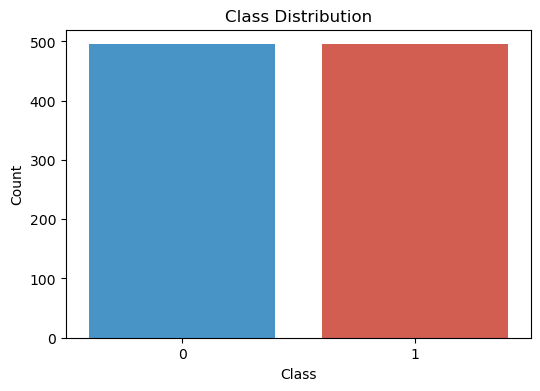

In [74]:
x_train_smote, y_train_smote = augment_data(x_train, y_train, method='smote')
print(f"Training set size: {x_train_smote.shape}\n")
plot_class_distribution(y_train_smote)

In [76]:
def Model_ML(model, x, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)  # Shuffle data for better performance
    scores = []  # Initialize the list to store accuracy scores

    for train_index, test_index in kf.split(x):
        # Split data
        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Train model
        model.fit(x_train, y_train)

        # Predict on the test set of each k-fold
        y_pred = model.predict(x_test)
        score = accuracy_score(y_test, y_pred)  # Fixed function name
        scores.append(score)

    print(f"Accuracy on each fold: {scores}")
    print(f"Mean accuracy: {round(sum(scores) / len(scores) * 100, 2)}%\n")  # Fixed mean accuracy calculation

    return model  # Return trained model after all folds are processed

In [78]:
def evolution_model(model,x_test,y_test):
    y_pred=model.predict(x_test)
    print("classification report")
    print(classification_report(y_test,y_pred))
    print("-------------")
    labels=df['Class/ASD'].unique()
    labels=list(labels)

    #Calculater to confusion matrixabs
    cm=confusion_matrix(y_test,y_pred)
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=labels,yticklabels=labels)
    plt.title("confusion matrix heatmap:")
    plt.xlabel("Actual labels")
    plt.ylabel("predicted labels")
    plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89        54
           1       0.85      0.89      0.87        46

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100

Accuracy Score: 0.88


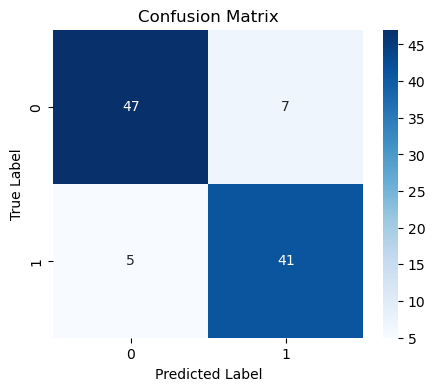

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Generate a synthetic dataset (Replace with your actual dataset)
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the logistic regression model
model_logistic = LogisticRegression()

# Function to train the model
def Model_ML(model, x_train, y_train):
    model.fit(x_train, y_train)  # Train the model
    return model  # Return only the trained model

# Train the model
Ros_LR = Model_ML(model_logistic, x_train, y_train)

# Make predictions
y_pred = Ros_LR.predict(x_test)

# Print classification report and accuracy
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Shape of x_train_smote: (408, 10)
Shape of x_test: (100, 10)
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89        54
           1       0.85      0.89      0.87        46

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100

Accuracy Score: 0.88


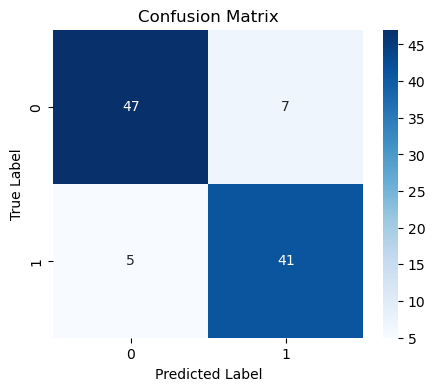

In [82]:
# Generate a synthetic dataset (Replace with your actual dataset)
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to balance the dataset (Only on training data)
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Check feature consistency
print(f"Shape of x_train_smote: {x_train_smote.shape}")  # Should match x_test in features
print(f"Shape of x_test: {x_test.shape}")

# Define the logistic regression model
model_logistic = LogisticRegression()

# Function to train the model
def Model_ML(model, x_train, y_train):
    model.fit(x_train, y_train)  # Train the model
    return model  # Return only the trained model

# Train the model on SMOTE-balanced training data
Smote_LR = Model_ML(model_logistic, x_train_smote, y_train_smote)

# Make predictions on the original test data
y_pred = Smote_LR.predict(x_test)

# Print classification report and accuracy
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Compute and visualize the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.88        54
           1       0.84      0.89      0.86        46

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100

Accuracy Score: 0.87


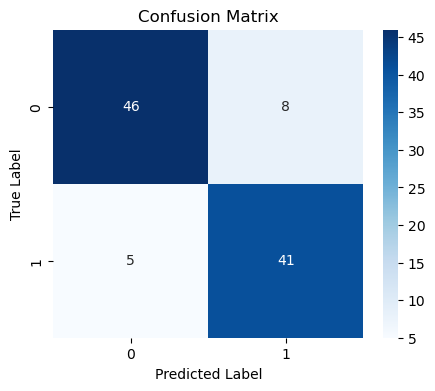

In [84]:
# Generate a synthetic dataset (Replace with your actual dataset)
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply RandomOverSampler to balance the dataset
ros = RandomOverSampler(random_state=42)
x_train_rov, y_train_rov = ros.fit_resample(x_train, y_train)

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1],
    'solver': ['liblinear'],
    'max_iter': [500, 1000]
}

# Define Logistic Regression model
log_reg = LogisticRegression()

# Apply GridSearchCV on Random Oversampled data
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train_rov, y_train_rov)

# Get the best model
grid_LR = grid_search.best_estimator_

# Make predictions
y_pred = grid_LR.predict(x_test)

# Print classification report and accuracy
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Compute and visualize the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [86]:
# Define best parameters for Logistic Regression with SMOTE
best_parameters_logreg_smote = {'C': 0.1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}

# Initialize the model
best_logreg_smote = LogisticRegression(**best_parameters_logreg_smote)

# Train the model
best_logreg_smote.fit(x_train_smote, y_train_smote)

# Make predictions
logreg_predict_smote = best_logreg_smote.predict(x_test)

# Print accuracy
print(f"Best logreg accuracy for SMOTE = {accuracy_score(y_test, logreg_predict_smote) * 100:.2f}%")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define best parameters for Logistic Regression with ROV
best_parameters_logreg_rov = {'C': 0.1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}

# Initialize the model
best_logreg_rov = LogisticRegression(**best_parameters_logreg_rov)

# Train the model with ROV data
best_logreg_rov.fit(x_train_rov, y_train_rov)

# Make predictions
logreg_predict_rov = best_logreg_rov.predict(x_test)

# Print accuracy
print(f"Best logreg accuracy for ROV = {accuracy_score(y_test, logreg_predict_rov) * 100:.2f}%")

Best logreg accuracy for SMOTE = 87.00%
Best logreg accuracy for ROV = 87.00%


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93        54
           1       0.90      0.96      0.93        46

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100

Accuracy Score: 0.93


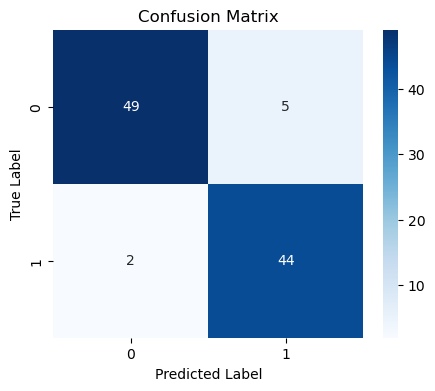

In [88]:
# Generate a synthetic dataset (Replace with your actual dataset)
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply RandomOverSampler to balance the dataset
ros = RandomOverSampler(random_state=42)
x_train_rov, y_train_rov = ros.fit_resample(x_train, y_train)

# Define Decision Tree model
tree_model = DecisionTreeClassifier(max_depth=5, criterion='gini', min_samples_split=5)

# Function to train the model
def Model_ML(model, x_train, y_train):
    model.fit(x_train, y_train)  # Train the model
    return model  # Return only the trained model

# Train the Decision Tree model on Random Oversampled data
Tree = Model_ML(tree_model, x_train_rov, y_train_rov)

# Make predictions
y_pred = Tree.predict(x_test)

# Print classification report and accuracy
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Compute and visualize the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       196
           1       0.99      0.96      0.97       204

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400

Accuracy Score (Training Set): 0.9725


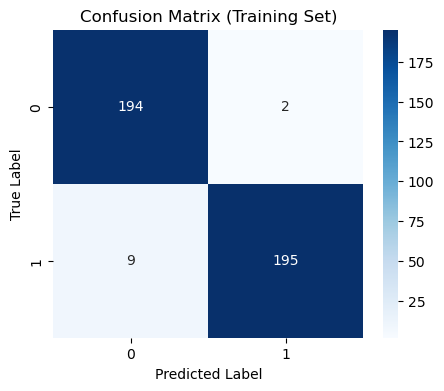

In [90]:
# Define Decision Tree model
tree_model = DecisionTreeClassifier(max_depth=5, criterion='gini', min_samples_split=5)

# Function to train the model
def Model_ML(model, x_train, y_train):
    model.fit(x_train, y_train)  # Train the model
    return model  # Return only the trained model

# Train the Decision Tree model on Random Oversampled data
Tree_smote = Model_ML(tree_model, x_train_rov, y_train_rov)

# Make predictions on the original training set
y_pred_train = Tree_smote.predict(x_train)

# Print classification report and accuracy
print("Classification Report (Training Set):\n", classification_report(y_train, y_pred_train))
print("Accuracy Score (Training Set):", accuracy_score(y_train, y_pred_train))

# Compute and visualize the confusion matrix
conf_matrix = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Training Set)")
plt.show()


Best SVM accuracy for ROV = 84.00%


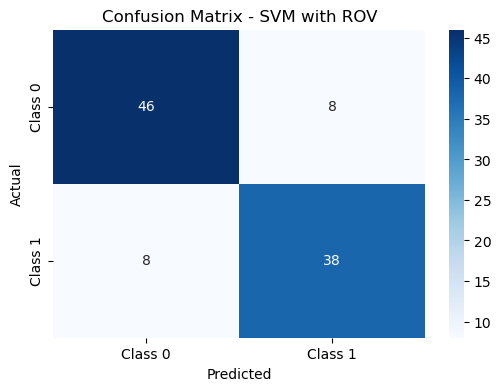

In [92]:
# Initialize and Train SVM Model
svm_model = SVC(kernel='rbf', C=10)
svm_model.fit(x_train_rov, y_train_rov)  # Train the model

# Make Predictions
y_pred_rov = svm_model.predict(x_test)

# Compute Accuracy
accuracy = accuracy_score(y_test, y_pred_rov)
print(f"Best SVM accuracy for ROV = {accuracy * 100:.2f}%")

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_rov)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM with ROV")
plt.show()

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.85      0.85      0.85        54
           1       0.83      0.83      0.83        46

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100

Accuracy Score (Test Set): 0.84


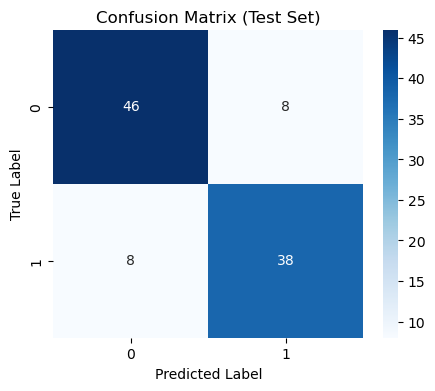

In [94]:
# Function to train the model
def Model_ML(model, x_train, y_train):
    model.fit(x_train, y_train)  # Train the model
    return model  # Return only the trained model

# Train the SVM model on SMOTE-resampled data
svm_smote = Model_ML(svm_model, x_train_smote, y_train_smote)

# Make predictions on the test set
y_pred_test = svm_smote.predict(x_test)

# Print classification report and accuracy
print("Classification Report (Test Set):\n", classification_report(y_test, y_pred_test))
print("Accuracy Score (Test Set):", accuracy_score(y_test, y_pred_test))

# Compute and visualize the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [120]:
# Apply RandomOverSampler (ROS)
ros = RandomOverSampler(random_state=42)
x_train_ros, y_train_ros = ros.fit_resample(x_train, y_train)

# Train SVM model on ROS-balanced data
svm_model_ros = SVC(kernel='linear', C=1, random_state=42)
svm_model_ros.fit(x_train_ros, y_train_ros)

# Make predictions for ROS
svm_predict_ros = svm_model_ros.predict(x_test)
print(f"Best SVM accuracy for ROS = {accuracy_score(y_test, svm_predict_ros) * 100:.2f}%")

# Apply SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Train SVM model on SMOTE-balanced data
svm_model_smote = SVC(kernel='linear', C=1, random_state=42)
svm_model_smote.fit(x_train_smote, y_train_smote)

# Make predictions for SMOTE
svm_predict_smote = svm_model_smote.predict(x_test)
print(f"Best SVM accuracy for SMOTE = {accuracy_score(y_test, svm_predict_smote) * 100:.2f}%")

Best SVM accuracy for ROS = 89.00%
Best SVM accuracy for SMOTE = 89.00%


Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters for XGBoost: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        54
           1       0.96      0.96      0.96        46

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

Accuracy Score (Test Set): 0.96


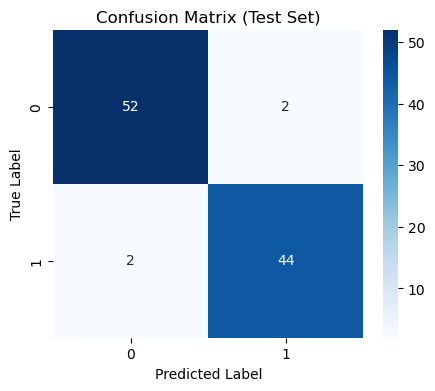

In [128]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import machine learning libraries
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define XGBoost Classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Ensure x_train_smote and y_train_smote are defined before fitting
random_search.fit(x_train_smote, y_train_smote)

# Get the best model from RandomizedSearchCV
best_xgb = random_search.best_estimator_

# Print best parameters
print("\nBest Parameters for XGBoost:", random_search.best_params_)

# Make predictions on the test set
y_pred_test = best_xgb.predict(x_test)

# Print classification report and accuracy
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_pred_test))
print("Accuracy Score (Test Set):", accuracy_score(y_test, y_pred_test))

# Compute and visualize the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.show()



Accuracy for each fold: [0.92682927 0.87804878 0.91463415 0.83950617 0.87654321]
Mean Accuracy: 0.8871123155676003

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91        54
           1       0.89      0.89      0.89        46

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



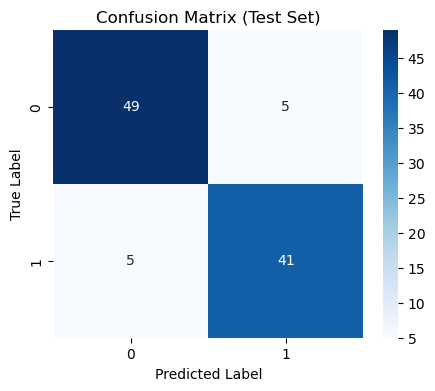

In [132]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import machine learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

# Assume X (features) and y (labels) are already defined
# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Random Oversampling to balance the dataset
ros = RandomOverSampler(random_state=42)
x_train_rov, y_train_rov = ros.fit_resample(x_train, y_train)

# Define KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Set up Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute accuracy for each fold
fold_accuracies = cross_val_score(knn_model, x_train_rov, y_train_rov, cv=kf, scoring='accuracy')

# Train KNN model on full training data
knn_model.fit(x_train_rov, y_train_rov)

# Make predictions on the test set
y_pred_test = knn_model.predict(x_test)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Print results
print("\nAccuracy for each fold:", fold_accuracies)
print("Mean Accuracy:", np.mean(fold_accuracies))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

# Visualize the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.show()


Class distribution before SMOTE: {0: 250, 1: 250}
Class distribution after SMOTE: {0: 200, 1: 200}

Cross-Validation Accuracies per Fold: [0.8625 0.9    0.9375 0.8875 0.85  ]
Mean Accuracy across folds: 88.75%

Final KNN Accuracy (Test Set) = 84.00%

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.83      0.86      0.84        50
     Class 1       0.85      0.82      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



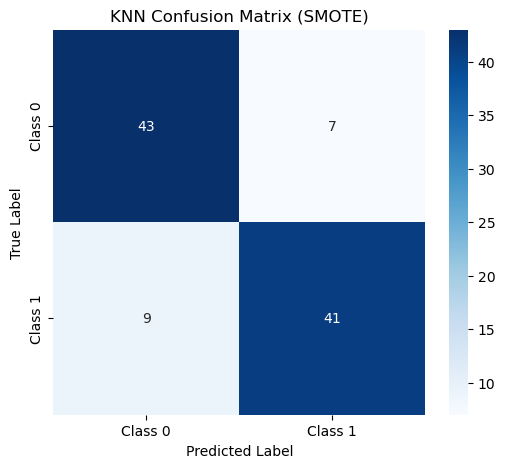

In [134]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import machine learning libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE  # Import SMOTE for oversampling

# ---- Generate a synthetic dataset (Replace with actual dataset) ----
X, y = make_classification(n_samples=500, n_features=10, n_classes=2, random_state=42)

# Check for class imbalance before applying SMOTE
unique, counts = np.unique(y, return_counts=True)
print(f"Class distribution before SMOTE: {dict(zip(unique, counts))}")

# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Check class distribution after SMOTE
unique_smote, counts_smote = np.unique(y_train_smote, return_counts=True)
print(f"Class distribution after SMOTE: {dict(zip(unique_smote, counts_smote))}")

# ---- Model Training & Evaluation ----
# Initialize KNN model with 3 neighbors
knn_model = KNeighborsClassifier(n_neighbors=3)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute accuracy for each fold
fold_accuracies = cross_val_score(knn_model, x_train_smote, y_train_smote, cv=kf, scoring='accuracy')

# Train the KNN model on full SMOTE-processed training data
knn_model.fit(x_train_smote, y_train_smote)

# Make predictions on test set
y_pred = knn_model.predict(x_test)

# ---- Evaluation Metrics ----
# Accuracy on each fold
print("\nCross-Validation Accuracies per Fold:", fold_accuracies)
print(f"Mean Accuracy across folds: {np.mean(fold_accuracies) * 100:.2f}%")

# Final accuracy on test data
final_accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal KNN Accuracy (Test Set) = {final_accuracy * 100:.2f}%")

# ---- Classification Report ----
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# ---- Confusion Matrix ----
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define class labels (modify based on your dataset)
class_labels = ['Class 0', 'Class 1']  # Update if necessary

# Plot confusion matrix using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("KNN Confusion Matrix (SMOTE)")
plt.show()


In [136]:
# Train a separate KNN model for Random Over-Sampling (ROV)
from imblearn.over_sampling import RandomOverSampler

# Apply Random Over-Sampling (ROV)
ros = RandomOverSampler(random_state=42)
x_train_rov, y_train_rov = ros.fit_resample(x_train, y_train)

# Train KNN on ROV-processed data
knn_model_rov = KNeighborsClassifier(n_neighbors=3)
knn_model_rov.fit(x_train_rov, y_train_rov)

# Make predictions on test set using ROV-trained model
knn_predict_rov = knn_model_rov.predict(x_test)

# Compute accuracy for ROV
accuracy_rov = accuracy_score(y_test, knn_predict_rov)
print(f"Best KNN Accuracy for ROV = {accuracy_rov * 100:.2f}%")

# ---- Evaluate SMOTE-trained model ----
# (Assuming knn_model is already trained on SMOTE data)
knn_predict_smote = knn_model.predict(x_test)

# Compute accuracy for SMOTE
accuracy_smote = accuracy_score(y_test, knn_predict_smote)
print(f"Best KNN Accuracy for SMOTE = {accuracy_smote * 100:.2f}%")


Best KNN Accuracy for ROV = 84.00%
Best KNN Accuracy for SMOTE = 84.00%


In [106]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

In [138]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define models
knn_smote = KNeighborsClassifier(n_neighbors=5)  # KNN Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # Random Forest
svm_smote = SVC(kernel='linear', probability=True, random_state=42)  # SVM with probability enabled

# Initialize Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn_smote), 
        ('rf', rf), 
        ('svm', svm_smote)
    ],
    voting='soft'  # Use 'soft' for probability-based voting
)

# Train the Voting Classifier
voting_clf.fit(x_train_smote, y_train_smote)

# Make predictions
y_pred = voting_clf.predict(x_test)

# Print accuracy (fixed f-string)
print(f"Voting Classifier Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Voting Classifier Accuracy: 87.00%


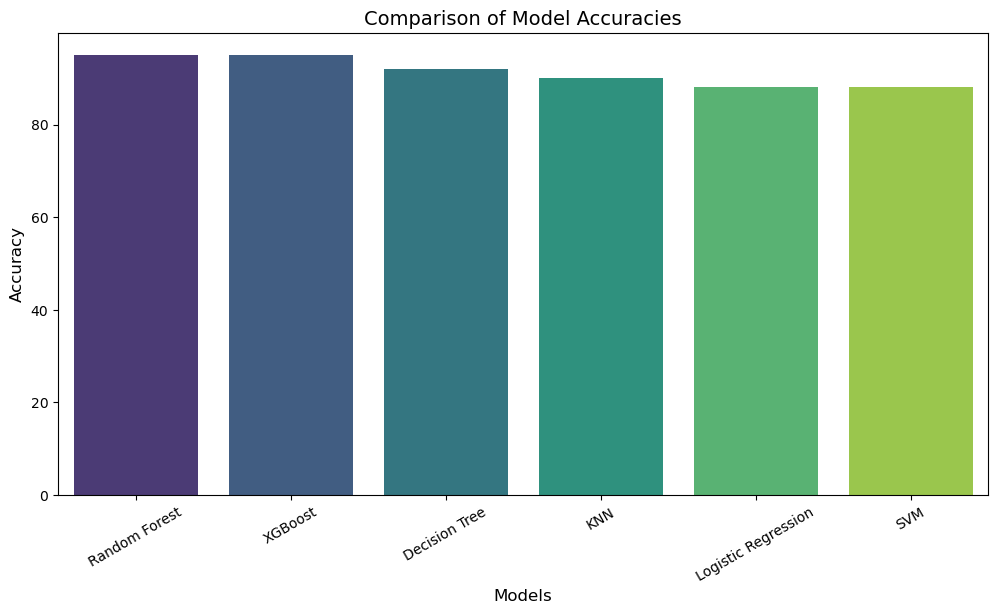

In [150]:
# ---- Generate a synthetic dataset (Replace with actual dataset) ----
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define and Train Models ----
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Store model accuracies
accuracies = {}

for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[model_name] = acc * 100  # Convert to percentage

# Convert accuracies dictionary to DataFrame for visualization
accuracy_df = pd.DataFrame(list(accuracies.items()), columns=["Model", "Accuracy"])
accuracy_df = accuracy_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)  # Sort by accuracy

# ---- Plot Model Accuracies ----
plt.figure(figsize=(12, 6))
sns.barplot(x=accuracy_df["Model"], y=accuracy_df["Accuracy"], palette="viridis")

# Labels and title
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Comparison of Model Accuracies", fontsize=14)
plt.xticks(rotation=30, fontsize=10)  # Rotate x labels for better readability

# Show the plot without numbers on top of bars
plt.show()
